<a href="https://colab.research.google.com/github/adityapawar7197-ops/PDS-PRACTICAL/blob/main/adi9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME :  ADITYA PAWAR

Branch : AI&DS

Roll NO. : SYB 25

Exp No.9

AIM :  Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.

Theory :

1 . What is a Data Science Pipeline? Explain its key stages with examples.

ANS.

 A Data Science Pipeline is a structured end-to-end workflow that transforms raw data into meaningful insights or predictions through a series of systematic steps. It ensures that the entire process is organized, repeatable, and efficient. The pipeline begins with data collection, where raw data is gathered from sources such as databases, APIs, CSV f iles, or web scraping. Next is data cleaning, where issues like missing values, duplicates, and outliers are handled to improve data quality. After that comes Exploratory Data Analysis (EDA), which helps understand patterns, distributions, and relationships using visual tools like histograms and correlation heatmaps. The next stage is feature engineering, where new features are created or transformed to improve model performance, such as creating an age group from an age column. Then comes data preprocessing, which includes encoding categorical variables, scaling numerical features, and splitting data into training and testing sets. After preprocessing, model building is performed by training machine learning algorithms such as Linear Regression or Decision Trees. The model is then evaluated using metrics like accuracy, R² score, or RMSE to check its performance. Finally, the model is deployed using tools like Flask or Streamlit so it can be used in real-world applications. For example, in a house price prediction system, we collect housing data, clean missing values, analyze price trends, create features like price per square foot, train a regression model, evaluate it using RMSE, and deploy it as a web application.







 2 . What is Exploratory Data Analysis (EDA)? How do univariate and bivariate analyses help?

 ANS.

  Exploratory Data Analysis (EDA) is the process of analyzing and summarizing datasets using statistical and visual methods to understand their structure, patterns, relationships, and anomalies before building machine learning models. It helps in identifying missing values, detecting outliers, understanding distributions, and validating assumptions. Univariate analysis focuses on examining a single variable at a time to  Colab understand its distribution and characteristics. Techniques such as histograms, box plots, bar charts, and descriptive statistics are used to check whether the data is skewed, to identify outliers, and to summarize key measures like mean and median. It answers questions like what the distribution of a variable looks like. On the other hand, bivariate analysis studies the relationship between two variables to understand how one affects another. Techniques like scatter plots, correlation heatmaps, grouped box plots, and cross-tabulation are used. For example, we can analyze how study hours relate to exam scores or how gender relates to salary distribution. Bivariate analysis helps in understanding relationships, dependencies, and potential predictive power between variables.






  3 . Differentiate between Label Encoding and OneHot Encoding. When should each be used?
  
  
  ANS.
  
  
  Label Encoding and OneHot Encoding are techniques used to convert categorical data into numerical format so that machine learning algorithms can process it. Label Encoding assigns a unique integer to each category, such as Red = 0, Green = 1, and Blue = 2. However, this method introduces an artificial order between categories, which may mislead some models. OneHot Encoding, on the other hand, creates separate binary columns for each category, where each row has a 1 or 0 indicating the presence of a category. For example, Red, Green, and Blue become three separate columns. Label Encoding is suitable for ordinal data where categories have a natural order, such as Low, Medium, and High, or for tree-based models like Decision Trees and Random Forests, which can handle integer values well. OneHot Encoding is preferred for nominal data where no order exists, such as colors, cities, or gender, and is especially useful for linear models, SVMs, and neural networks, which are sensitive to numerical relationships. While Label Encoding is memory efficient, OneHot Encoding increases dimensionality but avoids incorrect assumptions about order.

 4 . Why is Feature Scaling required? Compare Normalization and Standardization.

 ANS.

 Feature Scaling is an important preprocessing step in machine learning that transforms numerical features into a common scale so that no feature dominates the model due to its magnitude. It is especially important for algorithms like KNN, SVM, and gradientbased methods, where distance or scale significantly affects performance. Without scaling, features with large numerical ranges can overpower smaller ones and reduce model accuracy. Normalization, also known as Min-Max Scaling, transforms data into a f ixed range between 0 and 1 using the formula (X - Xmin) / (Xmax - Xmin). It is sensitive to outliers and is commonly used in neural networks, KNN, and image processing. Standardization, also called Z-score scaling, transforms data to have a mean of 0 and standard deviation of 1 using the formula (X - μ) / σ. It is less affected by outliers and is Colab preferred for algorithms like Linear Regression, Logistic Regression, SVM, and PCA. While normalization restricts data to a specific range, standardization does not have a f ixed range but centers the data, making it more suitable for normally distributed data.






 5 . What is Feature Engineering? Explain how creating new features can improve model performance.



 ANS.


  Feature Engineering is the process of creating, transforming, or selecting features from raw data using domain knowledge to improve the performance of machine learning models. It is one of the most important steps in the data science pipeline because good features often matter more than the choice of model. Feature engineering includes feature creation, where new variables are derived from existing ones, such as creating an Age Group from age or BMI from height and weight. It also includes feature transformation, such as applying log or square root transformations to reduce skewness. Feature extraction involves deriving meaningful information from raw data, such as extracting day, month, or year from a date column. Feature interaction combines two or more variables, such as calculating revenue from price multiplied by quantity. Binning converts continuous variables into categories, such as grouping ages into child, adult, and senior. Encoding converts categorical variables into numerical form using methods like Label or OneHot encoding. Feature engineering improves model performance by capturing hidden patterns, reducing noise, handling non-linear relationships, and improving interpretability. For example, in a housing dataset, creating a feature like rooms per square foot can provide better insight into space efficiency and significantly improve prediction accuracy compared to using raw features alone.


Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

STAGE 1: DATA COLLECTION (Synthetic Dataset)

In [ ]:
np.random.seed(42)
n = 100
data = pd.DataFrame({
    'Age': np.random.randint(18, 60, n),
    'Salary': np.random.randint(20000, 100000, n),
    'Experience': np.random.randint(0, 35, n),
    'Department': np.random.choice(['HR', 'IT', 'Finance', 'Marketing'], n),
    'Education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n), # Corrected unterminated string and added 'PhD'
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Performance': np.random.randint(50, 100, n)
})

# Introduce missing values
data.loc[np.random.choice(n, 8, replace=False), 'Salary']     = np.nan
data.loc[np.random.choice(n, 5, replace=False), 'Experience'] = np.nan

print("=== STAGE 1: Raw Dataset ===")
print(data.head(10))
print(f"\nShape: {data.shape}")

=== STAGE 1: Raw Dataset ===
   Age   Salary  Experience Department    Education  Gender  Performance
0   56  28392.0        18.0         HR  High School    Male           54
1   46  50535.0        19.0  Marketing          PhD    Male           84
2   32  98603.0        31.0         HR  High School    Male           61
3   25  72256.0         6.0         HR  High School  Female           74
4   38  55222.0        32.0    Finance     Bachelor  Female           70
5   56  97373.0        17.0         IT     Bachelor    Male           85
6   36      NaN         NaN  Marketing  High School  Female           72
7   40  83335.0        10.0    Finance       Master    Male           65
8   28  30965.0        27.0         HR     Bachelor    Male           88
9   28  44538.0        24.0         IT          PhD  Female           94

Shape: (100, 7)


STAGE 2: DATA CLEANING

In [ ]:
print("\n=== STAGE 2: Data Cleaning ===")
print("Missing values before cleaning:")
print(data.isnull().sum())

# Fill missing values
data['Salary'].fillna(data['Salary'].median(), inplace=True)
data['Experience'].fillna(data['Experience'].mean(), inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

print("\nMissing values after cleaning:")
print(data.isnull().sum())
print(f"\nShape after cleaning: {data.shape}")


=== STAGE 2: Data Cleaning ===
Missing values before cleaning:
Age            0
Salary         8
Experience     5
Department     0
Education      0
Gender         0
Performance    0
dtype: int64

Missing values after cleaning:
Age            0
Salary         0
Experience     0
Department     0
Education      0
Gender         0
Performance    0
dtype: int64

Shape after cleaning: (100, 7)


STAGE 3: EXPLORATORY DATA ANALYSIS (EDA)


=== STAGE 3: Exploratory Data Analysis ===
              Age        Salary  Experience  Performance
count  100.000000    100.000000  100.000000   100.000000
mean    37.910000  61952.460000   20.000000    75.610000
std     12.219454  21747.554885   10.353353    14.739417
min     18.000000  20206.000000    0.000000    50.000000
25%     26.750000  43748.000000   14.500000    62.000000
50%     38.000000  65419.000000   21.000000    76.000000
75%     46.250000  78811.500000   29.000000    88.000000
max     59.000000  99309.000000   34.000000    99.000000


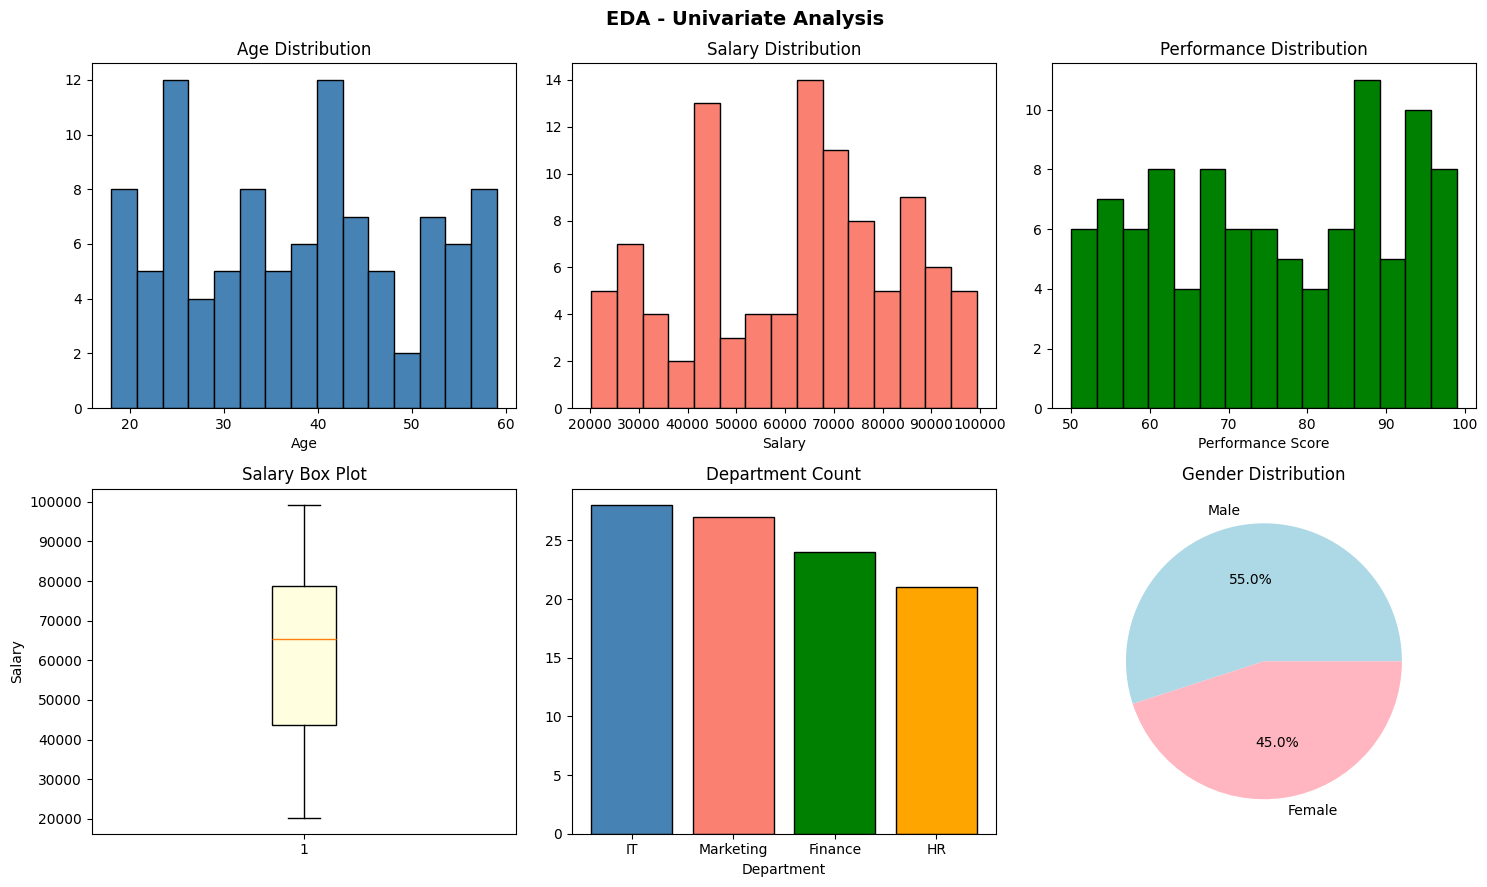

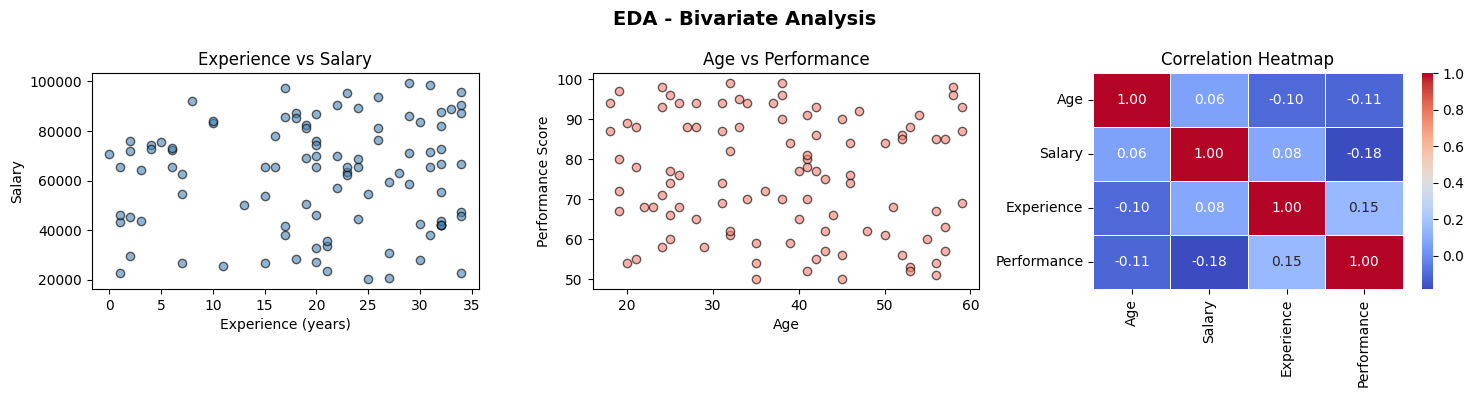

In [ ]:
print("\n=== STAGE 3: Exploratory Data Analysis ===")
print(data.describe())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('EDA - Univariate Analysis', fontsize=14, fontweight='bold')

# Histograms
axes[0, 0].hist(data['Age'], bins=15, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

axes[0, 1].hist(data['Salary'], bins=15, color='salmon', edgecolor='black')
axes[0, 1].set_title('Salary Distribution')
axes[0, 1].set_xlabel('Salary')

axes[0, 2].hist(data['Performance'], bins=15, color='green', edgecolor='black')
axes[0, 2].set_title('Performance Distribution')
axes[0, 2].set_xlabel('Performance Score')

# Box Plots
axes[1, 0].boxplot(data['Salary'], patch_artist=True, boxprops=dict(facecolor='lightyellow'))
axes[1, 0].set_title('Salary Box Plot')
axes[1, 0].set_ylabel('Salary')

# Bar Chart
dept_counts = data['Department'].value_counts()
axes[1, 1].bar(dept_counts.index, dept_counts.values, color=['steelblue','salmon','green','orange'], edgecolor='black')
axes[1, 1].set_title('Department Count')
axes[1, 1].set_xlabel('Department')

# Gender Pie Chart
gender_counts = data['Gender'].value_counts()
axes[1, 2].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightblue', 'lightpink'])
axes[1, 2].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

# Bivariate Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA - Bivariate Analysis', fontsize=14, fontweight='bold')

axes[0].scatter(data['Experience'], data['Salary'], color='steelblue', alpha=0.6, edgecolors='black')
axes[0].set_title('Experience vs Salary')
axes[0].set_xlabel('Experience (years)')
axes[0].set_ylabel('Salary')

axes[1].scatter(data['Age'], data['Performance'], color='salmon', alpha=0.6, edgecolors='black')
axes[1].set_title('Age vs Performance')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Performance Score')

numeric_cols = data[['Age', 'Salary', 'Experience', 'Performance']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

STAGE 4: FEATURE ENGINEERING

In [ ]:
print("\n=== STAGE 4: Feature Engineering ===")
# New Feature 1: Age Group (Binning)
data['Age_Group'] = pd.cut(data['Age'], bins=[0, 25, 40, 100],labels=['Young', 'Mid', 'Senior'])
# New Feature 2: Salary per Year of Experience
data['Salary_Per_Exp'] = data['Salary'] / (data['Experience'] + 1)
# New Feature 3: Log of Salary (reduce skewness)
data['Log_Salary'] = np.log1p(data['Salary'])
# New Feature 4: Performance Category
data['Perf_Category'] = pd.cut(data['Performance'], bins=[0, 65, 80, 100], labels=['Low', 'Medium', 'High'])
print("New features added:")
print(data[['Age', 'Age_Group', 'Salary', 'Salary_Per_Exp',
            'Log_Salary', 'Performance', 'Perf_Category']].head(8))


=== STAGE 4: Feature Engineering ===
New features added:
   Age Age_Group   Salary  Salary_Per_Exp  Log_Salary  Performance  \
0   56    Senior  28392.0     1494.315789   10.253898           54   
1   46    Senior  50535.0     2526.750000   10.830441           84   
2   32       Mid  98603.0     3081.343750   11.498867           61   
3   25     Young  72256.0    10322.285714   11.187984           74   
4   38       Mid  55222.0     1673.393939   10.919135           70   
5   56    Senior  97373.0     5409.611111   11.486315           85   
6   36       Mid  65419.0     3115.190476   11.088583           72   
7   40       Mid  83335.0     7575.909091   11.330636           65   

  Perf_Category  
0           Low  
1          High  
2           Low  
3        Medium  
4        Medium  
5          High  
6        Medium  
7           Low  


STAGE 5: ENCODING CATEGORICAL VARIABLES

In [ ]:
print("\n=== STAGE 5: Encoding Categorical Variables ===")
data_encoded = data.copy()

# Label Encoding - Ordinal: Education
edu_order = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
data_encoded['Education_Encoded'] = data_encoded['Education'].map(edu_order)

# Label Encoding - Ordinal: Age Group
age_order = {'Young': 0, 'Mid': 1, 'Senior': 2}
data_encoded['Age_Group_Encoded'] = data_encoded['Age_Group'].map(age_order)

# OneHot Encoding - Nominal: Department
dept_dummies = pd.get_dummies(data_encoded['Department'], prefix='Dept', drop_first=True)
data_encoded = pd.concat([data_encoded, dept_dummies], axis=1)

# Label Encoding - Binary: Gender
le = LabelEncoder()
data_encoded['Gender_Encoded'] = le.fit_transform(data_encoded['Gender'])

print("Label Encoding - Education:")
print(data_encoded[['Education', 'Education_Encoded']].drop_duplicates().sort_values(by='Education_Encoded'))

print("\nOneHot Encoding - Department columns added:")
print(dept_dummies.head(5))


=== STAGE 5: Encoding Categorical Variables ===
Label Encoding - Education:
     Education  Education_Encoded
0  High School                  0
4     Bachelor                  1
7       Master                  2
1          PhD                  3

OneHot Encoding - Department columns added:
   Dept_HR  Dept_IT  Dept_Marketing
0     True    False           False
1    False    False            True
2     True    False           False
3     True    False           False
4    False    False           False


STAGE 6: FEATURE SCALING


=== STAGE 6: Feature Scaling ===
Normalization (Min-Max) - first 5 rows:
   Age_Norm  Salary_Norm  Experience_Norm  Performance_Norm
0  0.926829     0.103485         0.529412          0.081633
1  0.682927     0.383412         0.558824          0.693878
2  0.341463     0.991075         0.911765          0.224490
3  0.170732     0.658003         0.176471          0.489796
4  0.487805     0.442663         0.941176          0.408163

Standardization (Z-Score) - first 5 rows:
    Age_Std  Salary_Std  Experience_Std  Performance_Std
0  1.487884   -1.550957       -0.194147        -1.473523
1  0.665394   -0.527645       -0.097074         0.572090
2 -0.486092    1.693762        1.067810        -0.996213
3 -1.061835    0.476166       -1.359031        -0.109781
4  0.007402   -0.311040        1.164884        -0.382530


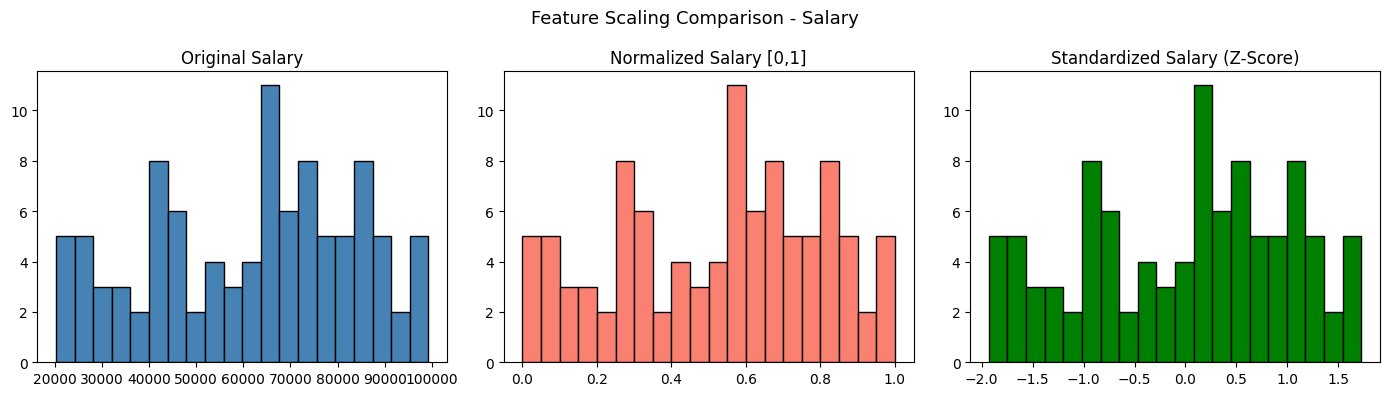

In [ ]:
print("\n=== STAGE 6: Feature Scaling ===")
scaler_minmax = MinMaxScaler()
scaler_std    = StandardScaler()
cols_to_scale = ['Age', 'Salary', 'Experience', 'Performance']
norm_scaled = scaler_minmax.fit_transform(data_encoded[cols_to_scale])
std_scaled  = scaler_std.fit_transform(data_encoded[cols_to_scale])
norm_df = pd.DataFrame(norm_scaled, columns=[c+'_Norm' for c in cols_to_scale])
std_df  = pd.DataFrame(std_scaled,  columns=[c+'_Std'  for c in cols_to_scale])

print("Normalization (Min-Max) - first 5 rows:")
print(norm_df.head())
print("\nStandardization (Z-Score) - first 5 rows:")
print(std_df.head())

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Feature Scaling Comparison - Salary', fontsize=13)

axes[0].hist(data['Salary'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Original Salary')

axes[1].hist(norm_df['Salary_Norm'], bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Normalized Salary [0,1]')

axes[2].hist(std_df['Salary_Std'], bins=20, color='green', edgecolor='black')
axes[2].set_title('Standardized Salary (Z-Score)')

plt.tight_layout()
plt.show()

STAGE 7: MODEL BUILDING & EVALUATION


=== STAGE 7: Model Building & Evaluation ===
Model     : Linear Regression
R² Score  : -0.2056
MSE       : 336.8815
RMSE      : 18.3543


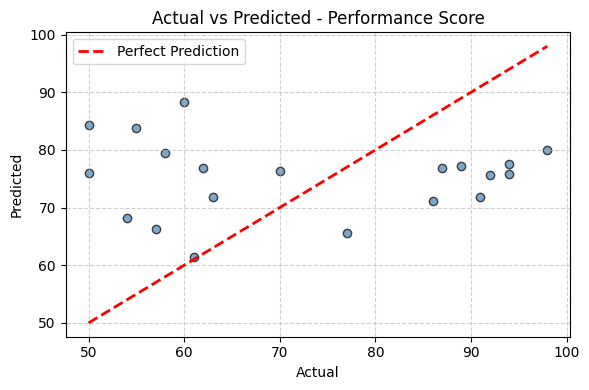


=== Pipeline Complete ===
Data Collection → Cleaning → EDA → Feature Engineering
→ Encoding → Scaling → Model Building → Evaluation


In [ ]:
print("\n=== STAGE 7: Model Building & Evaluation ===")
# Prepare features
feature_cols = ['Age', 'Experience', 'Education_Encoded', 'Gender_Encoded', 'Age_Group_Encoded'] + list(dept_dummies.columns)

data_encoded.reset_index(drop=True, inplace=True)
norm_df.reset_index(drop=True, inplace=True)

X = data_encoded[feature_cols].copy()
X[['Age', 'Experience']] = norm_df[['Age_Norm', 'Experience_Norm']]
Y = data_encoded['Performance']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

mse  = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(Y_test, Y_pred)

print(f"Model     : Linear Regression")
print(f"R² Score  : {r2:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 4))
plt.scatter(Y_test, Y_pred, color='steelblue', edgecolors='black', alpha=0.7)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted - Performance Score')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n=== Pipeline Complete ===")
print("Data Collection → Cleaning → EDA → Feature Engineering")
print("→ Encoding → Scaling → Model Building → Evaluation")

CONCLUSION :


This experiment successfully implemented a complete Data Science Pipeline integrating all previously learned techniques into a single end-to-end workflow. Starting from synthetic data creation, the pipeline covered data cleaning by handling missing values and duplicates, followed by Exploratory Data Analysis using both univariate and bivariate visualizations to understand distributions and relationships. Feature engineering added meaningful new variables like Age_Group, Salary_Per_Exp, and Log_Salary. Label Encoding was applied to ordinal variables like Education, while OneHot Encoding was used for nominal variables like Department. Both Min-Max Normalization and Z-Score Standardization were demonstrated and compared visually. Finally, a Linear Regression model was trained and evaluated using R², MSE, and RMSE metrics. This pipeline demonstrates how each stage contributes to building a reliable, interpretable, and production-ready machine learning model.